In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")

from lib.utils import constants
from lib.utils.seq_utils import get_mut_vectors

In [2]:
# Plot color
cmap1 = LinearSegmentedColormap.from_list("custom_cmap", ["white", "blue"])
cmap2 = LinearSegmentedColormap.from_list("custom_cmap", ["white", "red"])

In [3]:
# WT sequence
wt_seq = constants.HINGE_28 + constants.TM_28 + constants.COSTIM_28
wt_len = len(wt_seq)
split_num1 = len(constants.HINGE_28)
split_num2 = len(constants.HINGE_28 + constants.TM_28)


# Load data
df = pd.read_csv("../data/cytotoxicity/dataset.csv")
df.sequence = df.sequence.apply(lambda x: x[:wt_len])


# Select sequences
n = 10

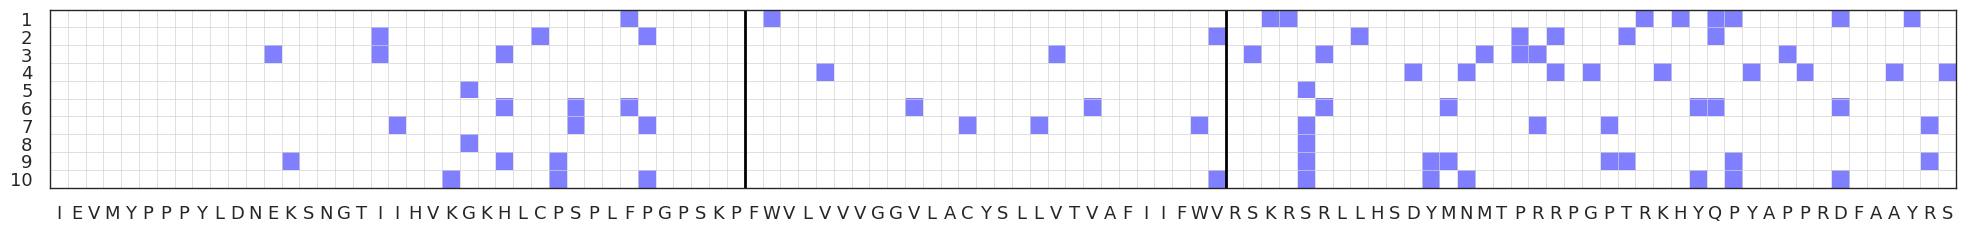

In [4]:
# Top-N sequences
df = df.sort_values("cytotoxic_activity", ascending=False)
top_seqs = df.iloc[:n].sequence.tolist()


# Visualize heatmap Top-N mutations
top_vecs = get_mut_vectors(top_seqs, wt_seq)
fig, ax = plt.subplots(figsize=(20, 5))
ax.imshow(pd.DataFrame(top_vecs), interpolation='nearest', vmin=0.0, vmax=2.0, cmap=cmap1)
for spine in ax.spines.values():
    spine.set_linewidth(1) 
ax.tick_params(axis='x', which='both', direction=None, top=False, bottom=True, labeltop=False, labelbottom=True)
ax.tick_params(axis='both', which='both', bottom=False, left=False)
ax.set_xticks(np.arange(len(wt_seq)), list(wt_seq), rotation=0, fontsize=13)
ax.set_yticks(np.arange(0, n), np.arange(1, n+1), fontsize=13)
plt.gca().set_xticks(np.arange(-0.5, wt_len), minor=True)
plt.gca().set_yticks(np.arange(-0.5, n), minor=True)
ax.grid(which='minor', color='lightgray', linewidth=0.5)
ax.axvline(split_num1-0.5, linewidth=2.0, color="black")
ax.axvline(split_num2-0.5, linewidth=2.0, color="black")
fig.tight_layout()
fig.savefig(f"./figures/mutation_positions_top{n}.svg")

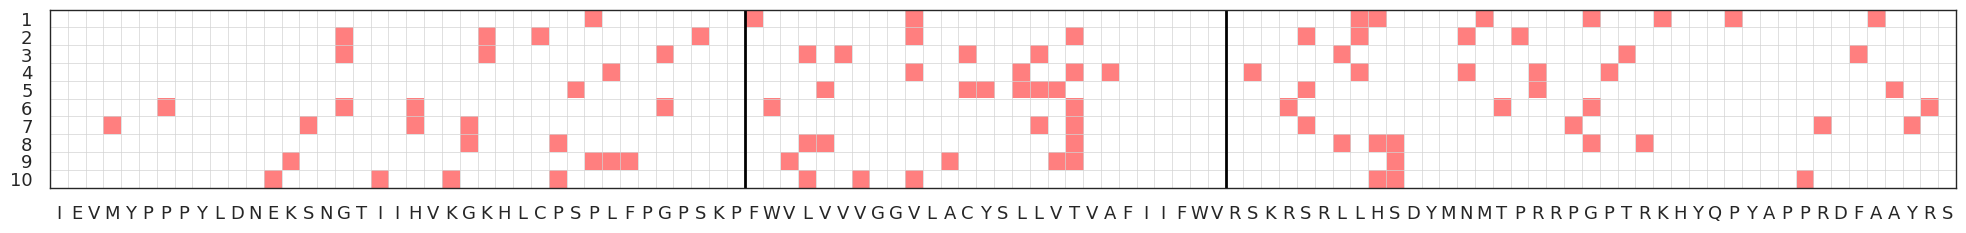

In [5]:
# Worst-N sequences
df = df.sort_values("cytotoxic_activity", ascending=True)
worst_seqs = df.iloc[:n].sequence.tolist()


# Visualize heatmap Worst-N mutations
worst_vecs = get_mut_vectors(worst_seqs, wt_seq)
fig, ax = plt.subplots(figsize=(20, 5))
ax.imshow(pd.DataFrame(worst_vecs), interpolation='nearest', vmin=0.0, vmax=2.0, cmap=cmap2)
for spine in ax.spines.values():
    spine.set_linewidth(1) 
ax.tick_params(axis='x', which='both', direction=None, top=False, bottom=True, labeltop=False, labelbottom=True)
ax.tick_params(axis='both', which='both', bottom=False, left=False)
ax.set_xticks(np.arange(len(wt_seq)), list(wt_seq), rotation=0, fontsize=13)
ax.set_yticks(np.arange(0, n), np.arange(1, n+1), fontsize=13)
plt.gca().set_xticks(np.arange(-0.5, wt_len), minor=True)
plt.gca().set_yticks(np.arange(-0.5, n), minor=True)
ax.grid(which='minor', color='lightgray', linewidth=0.5)
ax.axvline(split_num1-0.5, linewidth=2.0, color="black")
ax.axvline(split_num2-0.5, linewidth=2.0, color="black")
fig.tight_layout()
fig.savefig(f"./figures/mutation_positions_worst{n}.svg")